In [9]:
import sys
path_to_pip_installs = "/tmp/test_env"
if path_to_pip_installs not in sys.path:
    sys.path.insert(0, path_to_pip_installs)

path = "/home/students/studweilc1/MU-Diff/"
# add this to path for imports
if path not in sys.path:
    sys.path.append(path)

import os
import types
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as sk_psnr

from dataset.dataset_dixon import CreateDatasetSynthesis_single, CreateDatasetSynthesis_single_with_masks
from backbones.ncsnpp_generator_adagn_feat_single import NCSNpp, NCSNpp_adaptive

from backbones.dense_layer import conv2d 
from train_utils import (
    get_time_schedule,
    q_sample_pairs,
    sample_posterior,
    sample_from_model, 
    Diffusion_Coefficients,
    Posterior_Coefficients,
    _psnr_torch,
    parse_arguments,
    sample_from_model_single
)

# -------------------------
# Data loader
# -------------------------
def make_loader(args, phase="val", shuffle=False, input_path=None, contrast="T1_mapping_fl2d"):
    """
    Build a DataLoader exactly like in training (DistributedSampler removed for notebook use).
    """
    if input_path is None:
        input_path = args.input_path
    ds = CreateDatasetSynthesis_single(phase=phase, input_path=input_path, contrast=contrast, target_contrast="DIXON")
    loader = torch.utils.data.DataLoader(
        ds,
        batch_size=args.batch_size,
        shuffle=shuffle,
        num_workers=4,
        pin_memory=False,
        drop_last=False,
    )
    return loader

def make_loader_with_masks(args, phase="val", shuffle=False, input_path=None, contrast="T1_mapping_fl2d"):
    """
    Build a DataLoader with masks exactly like in training (DistributedSampler removed for notebook use).
    """
    if input_path is None:
        input_path = args.input_path
    
    ds = CreateDatasetSynthesis_single_with_masks(phase=phase, input_path=input_path, contrast=contrast, target_contrast="DIXON")
    loader = torch.utils.data.DataLoader(
        ds,
        batch_size=args.batch_size,
        shuffle=shuffle,
        num_workers=4,
        pin_memory=False,
        drop_last=False,
    )
    return loader

# -------------------------
# Model loading
# -------------------------
def _load_state_dict_strict(module, path, map_location):
    sd = torch.load(path, map_location=map_location)
    module.load_state_dict(sd)
    return module

def _load_state_dict_flex(module, src, map_location=None, strict=True):
    """
    Load a state_dict into `module`, handling DDP/DataParallel prefixes ("module.")
    and also accepting either a path or a dict.
    """
    print(f"Loading state_dict into {module.__class__.__name__} from {src}...")
    if isinstance(src, str):
        state = torch.load(src, map_location=map_location)
    else:
        state = src

    # Some projects save under 'state_dict'
    if isinstance(state, dict) and 'state_dict' in state and all(
        isinstance(k, str) for k in state['state_dict'].keys()
    ):
        state = state['state_dict']

    try:
        module.load_state_dict(state, strict=strict)
        return
    except RuntimeError as e:
        # Try stripping "module." once
        if isinstance(state, dict) and any(k.startswith('module.') for k in state.keys()):
            stripped = {k.replace('module.', '', 1): v for k, v in state.items()}
            module.load_state_dict(stripped, strict=strict)
            return
        raise e

def load_models(args, ckpt_dir, epoch=None, map_location=None, load_g2=True):
    """
    Load gen_diffusive_1 (and optionally gen_diffusive_2) + sampling helpers.

    Parameters
    ----------
    args : Namespace
        Same args object you use for training (must include num_timesteps, nz, etc.).
    ckpt_dir : str
        Directory with saved checkpoints (e.g., exp_path).
    epoch : int or None
        If provided, loads gen_diffusive_1_{epoch}.pth and gen_diffusive_2_{epoch}.pth.
        If None, tries to load from 'content.pth'.
    map_location : device or str
        e.g., 'cuda:0' or 'cpu'. If None, auto-selects CUDA if available.
    load_g2 : bool
        If False, only loads gen_diffusive_1.

    Returns
    -------
    device, gen1, gen2_or_None, coeff, pos_coeff, T
    """
    if map_location is None:
        map_location = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

    device = map_location if isinstance(map_location, torch.device) else torch.device(map_location)

    # Instantiate models exactly like train
    gen1 = NCSNpp(args).to(device).eval()
    gen2 = NCSNpp_adaptive(args).to(device).eval() if load_g2 else None

    # Load weights
    if epoch is not None:
        g1_path = os.path.join(ckpt_dir, f'gen_diffusive_1_{epoch}.pth')
        if not os.path.isfile(g1_path):
            raise FileNotFoundError(f"Missing {g1_path}")
        _load_state_dict_flex(gen1, g1_path, device)

        if load_g2:
            g2_path = os.path.join(ckpt_dir, f'gen_diffusive_2_{epoch}.pth')
            if not os.path.isfile(g2_path):
                raise FileNotFoundError(f"Missing {g2_path}")
            _load_state_dict_flex(gen2, g2_path, device)
    else:
        # fall back to content.pth (latest content snapshot from training)
        content_path = os.path.join(ckpt_dir, 'content.pth')
        if not os.path.isfile(content_path):
            raise FileNotFoundError(f"Provide epoch or ensure {content_path} exists.")
        content = torch.load(content_path, map_location=device)
        gen1.load_state_dict(content['gen_diffusive_1_dict'])
        if load_g2:
            gen2.load_state_dict(content['gen_diffusive_2_dict'])

    # Build sampling helpers exactly as in train
    coeff = Diffusion_Coefficients(args, device)
    pos_coeff = Posterior_Coefficients(args, device)
    T = get_time_schedule(args, device)

    # eval mode, no grads
    gen1.eval()
    if gen2 is not None:
        gen2.eval()
    torch.set_grad_enabled(False)

    return device, gen1, gen2, coeff, pos_coeff, T

# ----------------------------------------
# Predict with gen1 only (single-stage)
# ----------------------------------------
def _sample_from_model_g1_only(pos_coeff, gen1, cond1, cond2, cond3, num_steps, x_t, args):
    """
    Minimal faithful port of the inner loop you use in training:
    at each t, get x0_pred from gen1 and sample posterior to x_{t-1}.
    """
    device = x_t.device
    b = x_t.size(0)
    for i in reversed(range(num_steps)):
        t = torch.full((b,), i, device=device, dtype=torch.long)
        z = torch.randn(b, args.nz, device=device)
        x0_pred = gen1(x_t, cond1, cond2, cond3, t, z)              # shape [B, C(>=1), H, W], take channel 0 like train
        x_t = sample_posterior(pos_coeff, x0_pred[:, [0], :], x_t, t)
    return x_t

# ----------------------------------------
# Unified prediction function
# ----------------------------------------
def predict_sample(
    args,
    device,
    gen1,
    pos_coeff,
    T,
    *,
    gen2=None,
    cond1=None,
    num_timesteps=None,
    x_T=None,
    mode="both",         # "g1" or "both"
    seed=None,
):
    """
    Generate a sample using either only gen1 ("g1") or the two-stage path ("both")
    which calls your original sample_from_model.

    Inputs should be torch tensors already on `device` with shapes matching training:
      cond1, cond2, cond3: [B, 1, H, W] (or whatever your dataset returns)
    """
    assert mode in ("g1", "both"), "mode must be 'g1' or 'both'"

    if seed is not None:
        torch.manual_seed(seed)
        if device.type == "cuda":
            torch.cuda.manual_seed_all(seed)

    if num_timesteps is None:
        num_timesteps = args.num_timesteps

    # Make x_T if not given
    if x_T is None:
        # shape matches real_data from loader (use cond1’s shape for convenience)
        x_T = torch.randn_like(cond1)

    if mode == "both":
        if gen2 is None:
            raise ValueError("mode='both' requires gen2.")
        # Use the exact helper from training to ensure behavior parity
        out = sample_from_model_single(
            pos_coeff,
            gen1, cond1,
            gen2,
            num_timesteps,
            x_T, T, args
        )
        return out

    else:  # "g1"
        out = _sample_from_model_g1_only(
            pos_coeff,
            gen1,
            cond1,
            num_timesteps,
            x_T,
            args
        )
        return out

# ----------------------------------------
# Evaluation (exactly like validation loop)
# ----------------------------------------
def _to_range_0_1(x):
    return (x + 1.) / 2.

def eval_l1_psnr(fake, real, also_other_psnr=True):
    """
    Reproduces your validation metrics:
      - Convert to [0,1]
      - (a) divide-by-mean version
      - (b) without mean normalization
      - optional _psnr_torch just like the try/except in val loop

    Inputs: fake, real  (torch tensors, same shape)
    Returns dict of floats.
    """
    with torch.no_grad():
        fake_01 = _to_range_0_1(fake)
        real_01 = _to_range_0_1(real)

        # a) mean-normalized
        fake_div = fake_01 / fake_01.mean()
        real_div = real_01 / real_01.mean()

        fake_div_np = fake_div.detach().cpu().numpy()
        real_div_np = real_div.detach().cpu().numpy()
        l1_div = float(np.abs(fake_div_np - real_div_np).mean())
        psnr_div = float(sk_psnr(real_div_np, fake_div_np, data_range=real_div_np.max()))

        # b) without mean normalization
        fake_np = fake_01.detach().cpu().numpy()
        real_np = real_01.detach().cpu().numpy()
        l1_wmean = float(np.abs(fake_np - real_np).mean())
        psnr_wmean = float(sk_psnr(real_np, fake_np, data_range=real_np.max()))

        other_psnr = None
        if also_other_psnr:
            try:
                other_psnr = float(_psnr_torch(fake_01, real_01))
            except Exception:
                other_psnr = -1.0

    return {
        "l1_mean_norm": l1_div,
        "psnr_mean_norm": psnr_div,
        "l1_without_mean": l1_wmean,
        "psnr_without_mean": psnr_wmean,
        "psnr_other_fn": other_psnr,
    }

# ----------------------------------------
# Small convenience to fetch a single batch from a loader
# ----------------------------------------
def get_one_batch(loader, device):
    """
    Returns (cond1, cond2, cond3, gt) on device from the first batch.
    """
    batch = next(iter(loader))
    x1, x2, x3, x4 = batch
    return (
        x1.to(device, non_blocking=True),
        x2.to(device, non_blocking=True),
        x3.to(device, non_blocking=True),
        x4.to(device, non_blocking=True),
    )


def load_args_from_content(ckpt_dir, map_location='cpu'):
    """
    Load the saved args Namespace from a training content.pth file.

    Parameters
    ----------
    ckpt_dir : str
        Path to experiment directory (contains content.pth).
    map_location : str or torch.device
        Device for torch.load (args are just CPU objects, but safe to set).

    Returns
    -------
    args : argparse.Namespace
        The exact arguments object used during training.
    """
    content_path = os.path.join(ckpt_dir, "content.pth")
    if not os.path.isfile(content_path):
        raise FileNotFoundError(f"No content.pth in {ckpt_dir}")

    content = torch.load(content_path, map_location=map_location, weights_only=False)
    return content["args"]

# ===== Example usage in a notebook (adjust paths/args) =====
# args, _ = parse_arguments()    # or build your args Namespace manually for a notebook
# device, g1, g2, coeff, pos_coeff, T = load_models(args, ckpt_dir="/path/to/exp", epoch=100, load_g2=True)
# val_loader = make_loader(args, phase="val", shuffle=False)
# c1, c2, c3, gt = get_one_batch(val_loader, device)
#
# # --- two-stage prediction (same as training logs) ---
# x_T = torch.randn_like(gt)
# pred_both = predict_sample(args, device, g1, pos_coeff, T, gen2=g2, cond1=c1, cond2=c2, cond3=c3, x_T=x_T, mode="both")
# metrics_both = eval_l1_psnr(pred_both, gt)
#
# # --- gen1-only prediction ---
# x_T = torch.randn_like(gt)
# pred_g1 = predict_sample(args, device, g1, pos_coeff, T, gen2=None, cond1=c1, cond2=c2, cond3=c3, x_T=x_T, mode="g1")
# metrics_g1 = eval_l1_psnr(pred_g1, gt)
#
# print(metrics_both)
# print(metrics_g1)


In [ ]:
args = load_args_from_content("../results/exp_brats_single_T1")
device, g1, g2, coeff, pos_coeff, T = load_models(args, ckpt_dir="../results/exp_brats_single_T1", epoch=10, load_g2=True)
#val_loader = make_loader(args, phase="val", shuffle=False, input_path="../data/my_data3")
#train_loader = make_loader(args, phase="train", shuffle=False, input_path="../data/my_data3")
test_loader = make_loader_with_masks(args, phase="test", shuffle=False, input_path="../data/my_data3")

Loading state_dict into NCSNpp from ../results/exp_brats_single_T1/gen_diffusive_1_10.pth...
Loading state_dict into NCSNpp_adaptive from ../results/exp_brats_single_T1/gen_diffusive_2_10.pth...
padding in x-y with:0-0
padding in x-y with:0-0


In [48]:
def predict_target(val_loader, index=0, mode="both"):
    c1,target,m1,m_target = val_loader.dataset[index]
    c1 = c1.unsqueeze(0).to(device)
    target = target.unsqueeze(0).to(device)
    x_T = torch.randn_like(target)
    fake_target = predict_sample(args, device, g1, pos_coeff, T, gen2=g2, cond1=c1, x_T=x_T, mode="both")
    return fake_target

Text(0.5, 1.0, 'Ground Truth Mask')

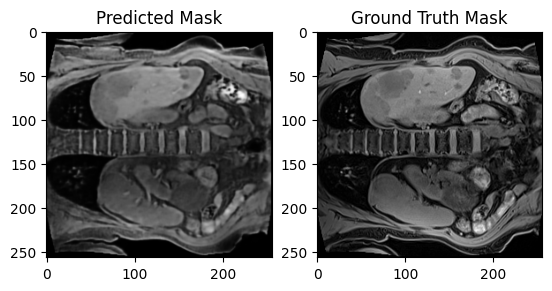

In [ ]:
fake_target = predict_target(test_loader, index=0, mode="both")

fig, axs = plt.subplots(1,2)
axs[0].imshow(fake_target[0,0].cpu().detach().numpy(), cmap='gray')
axs[0].set_title('Predicted Mask')
axs[1].imshow(test_loader.dataset[0][1][0].cpu().detach().numpy(), cmap='gray')
axs[1].set_title('Ground Truth Mask')

In [62]:
def predict_target_mask(val_loader, index=0, mode="both"):
    c1,target,m1,m_target = val_loader.dataset[index]
    c1 = c1.clone()
    c1[m1==1] = 0.0
    c1 = c1.unsqueeze(0).to(device)
    target = target.unsqueeze(0).to(device)
    x_T = torch.randn_like(target)
    fake_target = predict_sample(args, device, g1, pos_coeff, T, gen2=g2, cond1=c1, x_T=x_T, mode=mode)
    return fake_target, c1,target,m1,m_target

def predict_target(val_loader, index=0, mode="both"):
    c1,target,m1,m_target = val_loader.dataset[index]
    c1 = c1.unsqueeze(0).to(device)
    target = target.unsqueeze(0).to(device)
    x_T = torch.randn_like(target)
    fake_target = predict_sample(args, device, g1, pos_coeff, T, gen2=g2, cond1=c1, x_T=x_T, mode=mode)
    return fake_target

In [63]:
fake_target_with_mask,c1,target,m1,m_target = predict_target_mask(test_loader, index=10, mode="both")
fake_target = predict_target(test_loader, index=10, mode="both")


Text(0.5, 1.0, 'Difference Mask with DIXON')

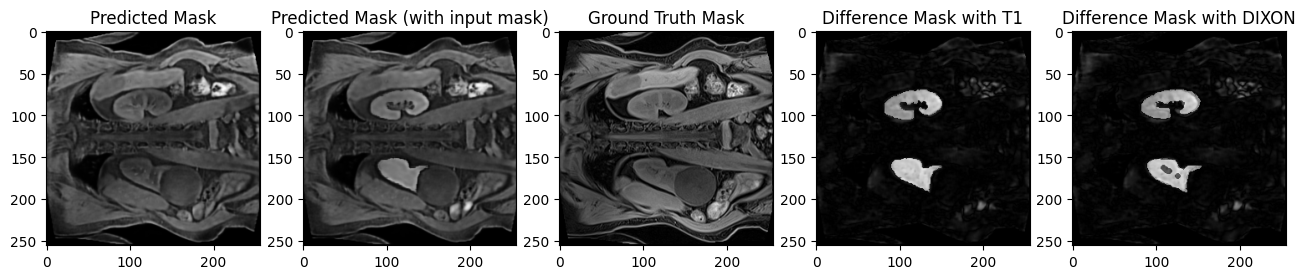

In [76]:
fk_target = fake_target.clone()[0,0]
fk_target_with_mask = fake_target_with_mask.clone()[0,0]



fig, axs = plt.subplots(1,5, figsize=(16,4))
axs[0].imshow(fk_target.cpu().detach().numpy(), cmap='gray')
axs[0].set_title('Predicted Mask')
axs[1].imshow(fk_target_with_mask.cpu().detach().numpy(), cmap='gray')
axs[1].set_title('Predicted Mask (with input mask)')
axs[2].imshow(target[0,0].cpu().detach().numpy(), cmap='gray')
axs[2].set_title('Ground Truth Mask')
diff_targets = torch.abs(fk_target - fk_target_with_mask)
axs[3].imshow(diff_targets.cpu().detach().numpy(), cmap='gray')
axs[3].imshow(m1.cpu().detach().numpy()[0], cmap='gray', alpha=0.5)
axs[3].set_title('Difference Mask with T1')
axs[4].imshow(diff_targets.cpu().detach().numpy(), cmap='gray')
axs[4].imshow(m_target.cpu().detach().numpy()[0], cmap='gray', alpha=0.5)
axs[4].set_title('Difference Mask with DIXON')

<function matplotlib.pyplot.imshow(X: 'ArrayLike | PIL.Image.Image', cmap: 'str | Colormap | None' = None, norm: 'str | Normalize | None' = None, *, aspect: "Literal['equal', 'auto'] | float | None" = None, interpolation: 'str | None' = None, alpha: 'float | ArrayLike | None' = None, vmin: 'float | None' = None, vmax: 'float | None' = None, colorizer: 'Colorizer | None' = None, origin: "Literal['upper', 'lower'] | None" = None, extent: 'tuple[float, float, float, float] | None' = None, interpolation_stage: "Literal['data', 'rgba', 'auto'] | None" = None, filternorm: 'bool' = True, filterrad: 'float' = 4.0, resample: 'bool | None' = None, url: 'str | None' = None, data=None, **kwargs) -> 'AxesImage'>

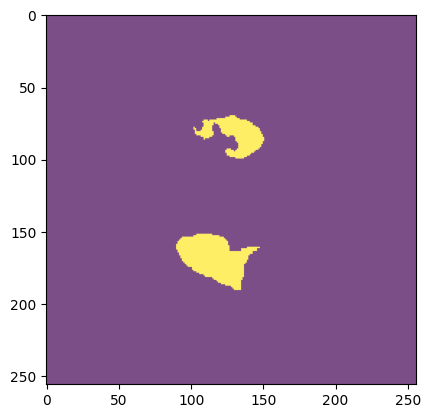

In [106]:
import numpy as np
from scipy import ndimage as ndi

def estimate_bright_mask(
    img: np.ndarray,
    roi: tuple = ((50, 200), (50, 200)),  # ((ymin, ymax), (xmin, xmax))
    gaussian_sigma: float = 1.5,
    min_component_area: int = 500,
    keep_only_largest: bool = True,
    return_uint8: bool = True
) -> np.ndarray:
    """
    Estimate a binary mask for the main bright area in a 256x256 image,
    restricted to a rectangular region of interest (ROI).

    Parameters
    ----------
    img : np.ndarray
        2D array (256, 256). Can be uint8/uint16/float.
    roi : tuple
        ((ymin, ymax), (xmin, xmax)) region where brightness is evaluated.
        Outside the ROI, mask will be 0.
    gaussian_sigma : float
        Smoothing before thresholding.
    min_component_area : int
        Remove connected components smaller than this many pixels.
    keep_only_largest : bool
        If True, keep only the single largest bright component.
    return_uint8 : bool
        If True, return {0,255} mask; otherwise boolean.

    Returns
    -------
    np.ndarray
        Binary mask (uint8 or bool).
    """
    if img.ndim != 2:
        raise ValueError("img must be a 2D array")

    img = img.astype(np.float32)

    (ymin, ymax), (xmin, xmax) = roi
    img_roi = img[ymin:ymax, xmin:xmax]

    # Normalize only within ROI
    vmin, vmax = np.percentile(img_roi, [0.5, 99.5])
    if vmax <= vmin:
        vmax = img_roi.max() if img_roi.max() > vmin else vmin + 1.0
    img_norm = np.clip((img - vmin) / (vmax - vmin), 0, 1)

    # Smooth to reduce noise
    if gaussian_sigma > 0:
        img_s = ndi.gaussian_filter(img_norm, gaussian_sigma)
    else:
        img_s = img_norm

    # Threshold within ROI
    roi_region = img_s[ymin:ymax, xmin:xmax]
    hist, bin_edges = np.histogram(roi_region, bins=256, range=(0.0, 1.0))
    prob = hist / hist.sum()
    omega = np.cumsum(prob)
    mu = np.cumsum(prob * (bin_edges[:-1] + (bin_edges[1:] - bin_edges[:-1]) * 0.5))
    mu_t = mu[-1]
    sigma_b2 = (mu_t * omega - mu)**2 / np.maximum(omega * (1.0 - omega), 1e-12)
    thr = bin_edges[np.nanargmax(sigma_b2)]

    mask = np.zeros_like(img_s, dtype=bool)
    mask[ymin:ymax, xmin:xmax] = roi_region >= thr

    # Remove small components and keep largest if requested
    if min_component_area > 0:
        labeled, n = ndi.label(mask)
        if n > 0:
            sizes = np.bincount(labeled.ravel())
            keep = np.where(sizes >= min_component_area)[0]
            keep = keep[keep != 0]
            mask = np.isin(labeled, keep)

    if keep_only_largest:
        labeled, n = ndi.label(mask)
        if n > 1:
            sizes = np.bincount(labeled.ravel())
            sizes[0] = 0
            largest = sizes.argmax()
            mask = (labeled == largest)

    mask = ndi.binary_fill_holes(mask)

    return (mask.astype(np.uint8) * 255) if return_uint8 else mask





diff_tmp = diff_targets.cpu().detach().numpy()
diff_tmp_mask = estimate_bright_mask(diff_tmp, gaussian_sigma=0.5, min_component_area=100, keep_only_largest=False, return_uint8=False)

diff_tmp_mask_torch = torch.from_numpy(diff_tmp_mask)

plt.imshow(diff_tmp_mask, alpha=0.7)
plt.imshow


In [97]:
from monai.metrics import DiceMetric
dice_metric = DiceMetric(include_background=True, reduction="mean")

In [100]:
dice_metric(m1.unsqueeze(0), m_target.unsqueeze(0))

tensor([[0.8943]])

In [103]:
dice_metric(diff_tmp_mask_torch.unsqueeze(0).unsqueeze(0), m_target.unsqueeze(0))

tensor([[0.7393]])

In [105]:
dice_metric(diff_tmp_mask_torch.unsqueeze(0).unsqueeze(0), m1.unsqueeze(0))

tensor([[0.8130]])